## Importation and configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

## SECTION 1: DATA LOADING AND PREPARATION

In [90]:
def load_data(filepath, date_columns=None):
    """
    Loads CSV data and converts date columns

    Args:
        filepath: Path to the CSV file
        date_columns: List of columns to convert to datetime

    Returns:
        pandas DataFrame
    """
    df = pd.read_csv(filepath, index_col=False)

    if date_columns:
        for col in date_columns:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors="coerce")

    return df

In [13]:
def get_data_summary(df):
    """
    Displays a summary of the data

    Args:
        df: DataFrame to analyze
    """
    print("=" * 80)
    print("DATA SUMMARY")
    print("=" * 80)
    print(f"\nTotal number of MRs: {len(df)}")
    print(f"Number of projects: {df['Project_ID'].nunique()}")
    print(
        f"\nCovered period: {df['Creation_Date'].min()} to {df['Creation_Date'].max()}"
    )
    print("\nAvailable columns:")
    for col in df.columns:
        print(f"  - {col}")
    print("\n" + "=" * 80)

In [91]:
df = load_data("data/efforts_results_250833.csv", date_columns=["Creation_Date"])
get_data_summary(df)

DATA SUMMARY

Total number of MRs: 4417
Number of projects: 1

Covered period: 2015-05-02 02:38:50 to 2023-10-30 14:15:00

Available columns:
  - Project_ID
  - MR_ID
  - Creation_Date
  - Lead_Time
  - #Discussions
  - #Commits
  - Mean_Time_between_commits
  - Commiters
  - #UniqueCommiters
  - nb_minor_author
  - nb_major_author
  - delta_time
  - churn_addition
  - churn_deletions
  - initial_mr_size
  - hist_entropy
  - modified_files
  - filetypes
  - state
  - rework_size
  - #people
  - #reviewers
  - #commiters
  - #discussionners
  - additions
  - deletions
  - comments



## SECTION 2: Time Series Analysis

In [94]:
def plot_commits_over_time(
    df, date_col="Creation_Date", commit_col="#Commits", freq="M", figsize=(12, 6)
):
    """
    Plot the number of commits over time

    Args:
        df: DataFrame
        date_col: Name of the date column
        commit_col: Name of the commits column
        freq: Aggregation frequency ('D'=day, 'W'=week, 'M'=month)
        figsize: Figure size
    """
    df_copy = df.copy()
    df_copy["period"] = df_copy[date_col].dt.to_period(freq)

    commits_by_period = df_copy.groupby("period")[commit_col].sum()

    plt.figure(figsize=figsize)
    commits_by_period.plot(kind="line", marker="o")
    plt.title(
        f"Number of commits over time (aggregated by {freq})",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Period", fontsize=12)
    plt.ylabel("Total number of commits", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return commits_by_period

In [96]:
def plot_mr_creation_timeline(df, date_col="Creation_Date", freq="W", figsize=(12, 6)):
    """
    Plot the timeline of MR creation

    Args:
        df: DataFrame
        date_col: Name of the date column
        freq: Aggregation frequency
        figsize: Figure size
    """
    df_copy = df.copy()
    df_copy["period"] = df_copy[date_col].dt.to_period(freq)

    mrs_by_period = df_copy.groupby("period").size()

    plt.figure(figsize=figsize)
    mrs_by_period.plot(kind="bar", color="steelblue")
    plt.title(
        f"Number of MRs created per period ({freq})", fontsize=14, fontweight="bold"
    )
    plt.xlabel("Period", fontsize=12)
    plt.ylabel("Number of MRs", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    return mrs_by_period

In [97]:
def plot_lead_time_distribution(df, lead_time_col="Lead_Time", figsize=(12, 6)):
    """
    Distribution of Lead Time

    Args:
        df: DataFrame
        lead_time_col: Name of the lead time column
        figsize: Figure size
    """
    df_filtered = df[df[lead_time_col] != "open"].copy()
    df_filtered[lead_time_col] = pd.to_numeric(
        df_filtered[lead_time_col], errors="coerce"
    )
    df_filtered = df_filtered.dropna(subset=[lead_time_col])

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Histogram
    axes[0].hist(
        df_filtered[lead_time_col], bins=30, color="skyblue", edgecolor="black"
    )
    axes[0].set_title("Lead Time Distribution", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Lead Time (hours)", fontsize=10)
    axes[0].set_ylabel("Frequency", fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Box plot
    axes[1].boxplot(df_filtered[lead_time_col], vert=True)
    axes[1].set_title("Lead Time Box Plot", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Lead Time (hours)", fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    stats = df_filtered[lead_time_col].describe()
    print(f"\nLead Time statistics:\n{stats}")

    return stats

## Test Case : 

1.1 - Evolution of commits over time (by month)...


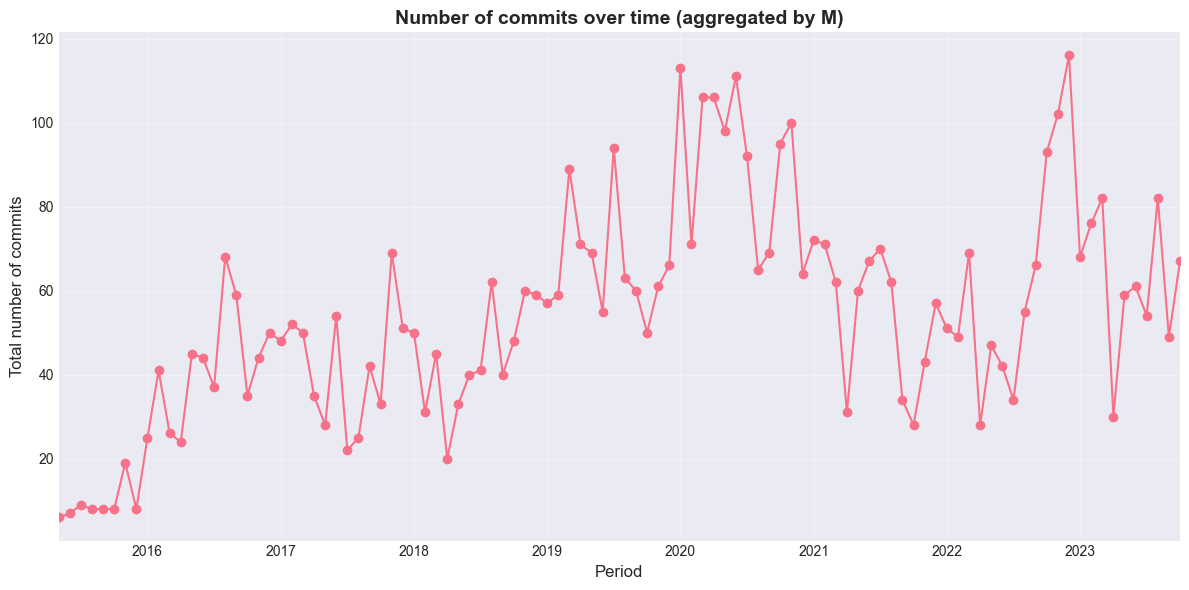

1.2 - Evolution of commits over time (by week)...


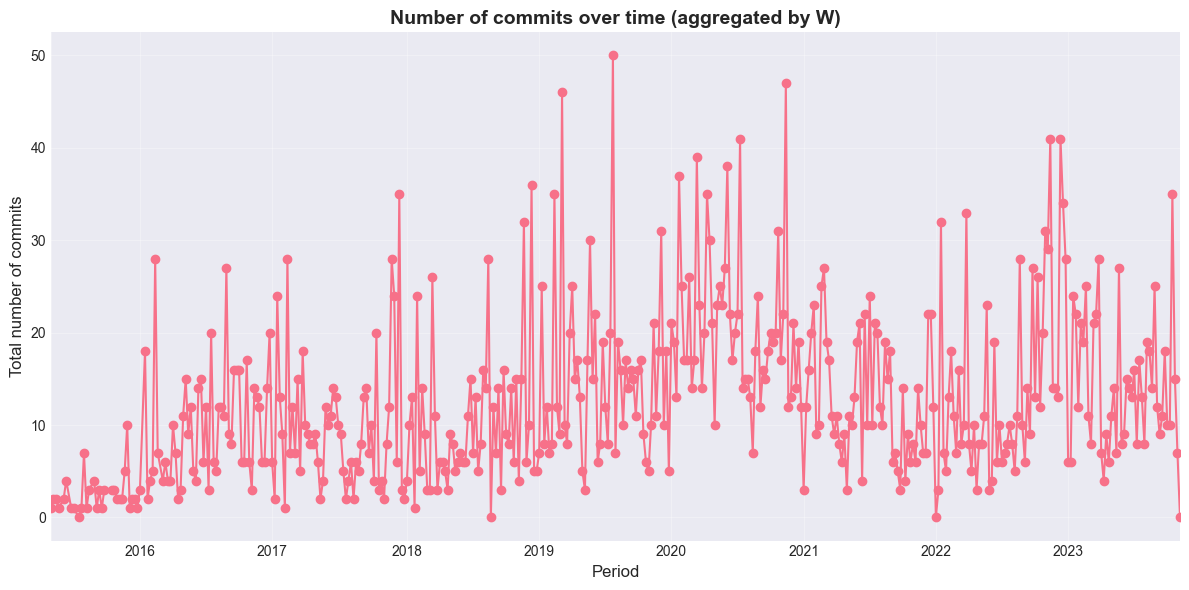

1.3 - MR creation timeline...


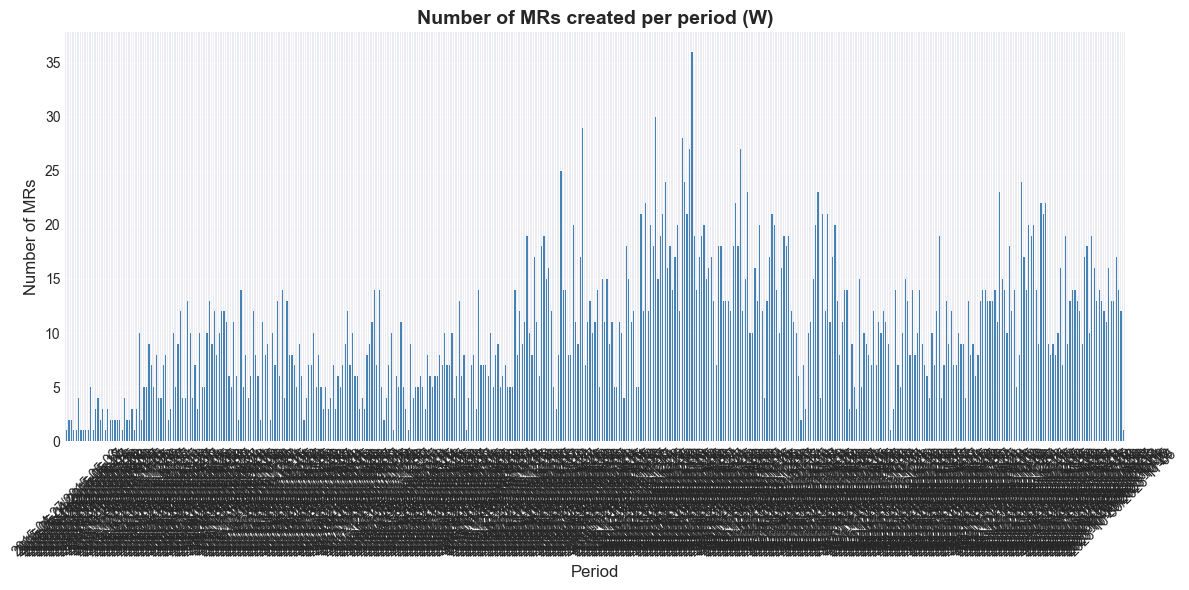

1.4 - Lead Time distribution...


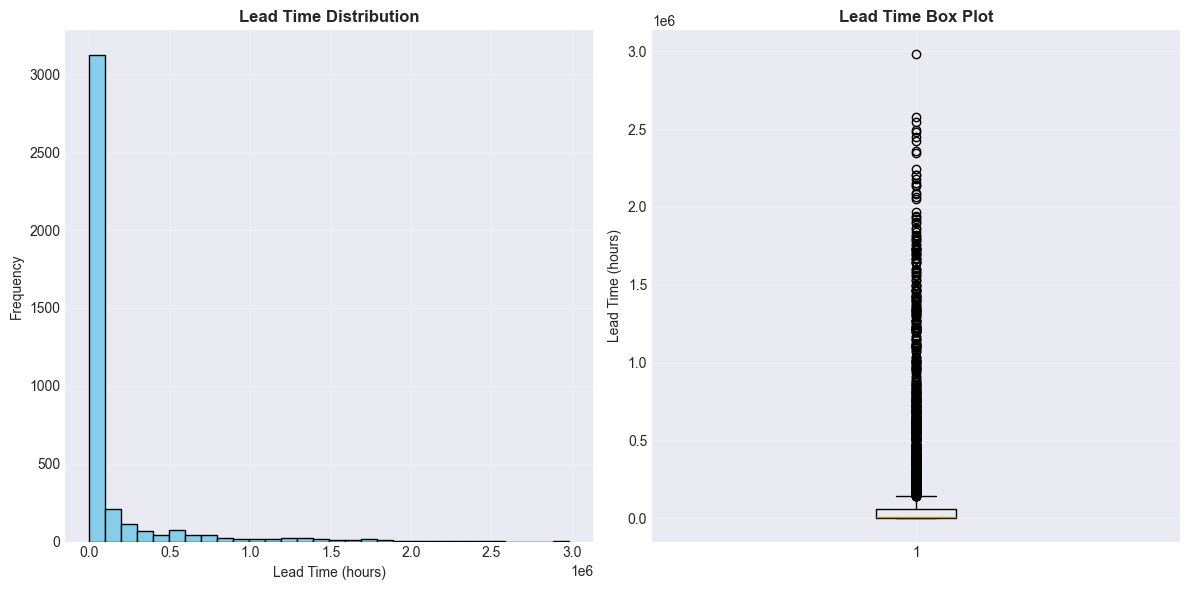


Lead Time statistics:
count    3.918000e+03
mean     1.332265e+05
std      3.404678e+05
min      1.000000e-01
25%      1.044433e+03
50%      7.864217e+03
75%      5.723440e+04
max      2.984896e+06
Name: Lead_Time, dtype: float64


In [98]:
print("1.1 - Evolution of commits over time (by month)...")
commits_by_month = plot_commits_over_time(
    df, date_col="Creation_Date", commit_col="#Commits", freq="M"
)

print("1.2 - Evolution of commits over time (by week)...")
commits_by_week = plot_commits_over_time(
    df, date_col="Creation_Date", commit_col="#Commits", freq="W"
)

print("1.3 - MR creation timeline...")
mrs_timeline = plot_mr_creation_timeline(df, date_col="Creation_Date", freq="W")

print("1.4 - Lead Time distribution...")
lead_time_stats = plot_lead_time_distribution(df, lead_time_col="Lead_Time")

## SECTION 3: COMMITS ANALYSIS

In [17]:
def plot_commits_distribution(df, commit_col="#Commits", figsize=(10, 6)):
    """
    Distribution of the number of commits per MR

    Args:
        df: DataFrame
        commit_col: Name of the commits column
        figsize: Figure size
    """
    plt.figure(figsize=figsize)

    df[commit_col].value_counts().sort_index().plot(kind="bar", color="coral")
    plt.title(
        "Distribution of the number of commits per MR", fontsize=14, fontweight="bold"
    )
    plt.xlabel("Number of commits", fontsize=12)
    plt.ylabel("Number of MRs", fontsize=12)
    plt.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    stats = df[commit_col].describe()
    print(f"\nCommit statistics:\n{stats}")

    return stats

In [18]:
def plot_commiters_analysis(df, commiters_col="#UniqueCommiters", figsize=(10, 6)):
    """
    Analysis of the number of unique contributors

    Args:
        df: DataFrame
        commiters_col: Name of the unique contributors column
        figsize: Figure size
    """
    plt.figure(figsize=figsize)

    commiters_dist = df[commiters_col].value_counts().sort_index()
    commiters_dist.plot(kind="bar", color="lightgreen")
    plt.title(
        "Distribution of the number of unique contributors per MR",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Number of contributors", fontsize=12)
    plt.ylabel("Number of MRs", fontsize=12)
    plt.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    return commiters_dist

In [19]:
def plot_commit_time_analysis(
    df, time_col="Mean_Time_between_commits", figsize=(10, 6)
):
    """
    Analysis of the average time between commits

    Args:
        df: DataFrame
        time_col: Name of the time between commits column
        figsize: Figure size
    """
    df_filtered = df[df[time_col] > 0].copy()

    plt.figure(figsize=figsize)
    plt.hist(df_filtered[time_col], bins=30, color="mediumpurple", edgecolor="black")
    plt.title(
        "Distribution of the average time between commits",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Average time (hours)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    stats = df_filtered[time_col].describe()
    print(f"\nStatistics of time between commits:\n{stats}")

    return stats

## Test Case : 

2.1 - Distribution of the number of commits per MR...


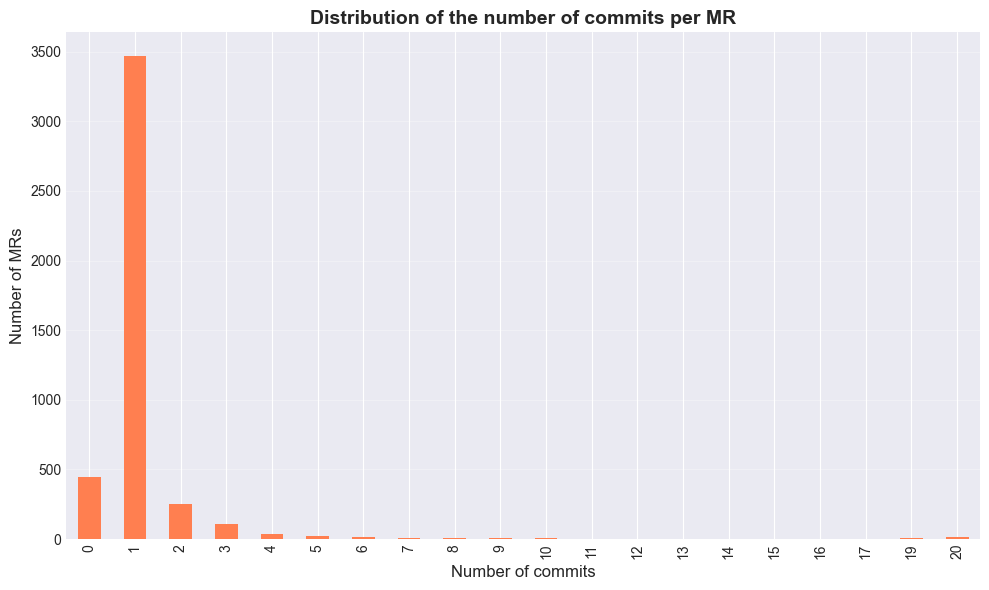


Commit statistics:
count    4417.000000
mean        1.251981
std         1.738220
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        20.000000
Name: #Commits, dtype: float64
2.2 - Analysis of unique contributors...


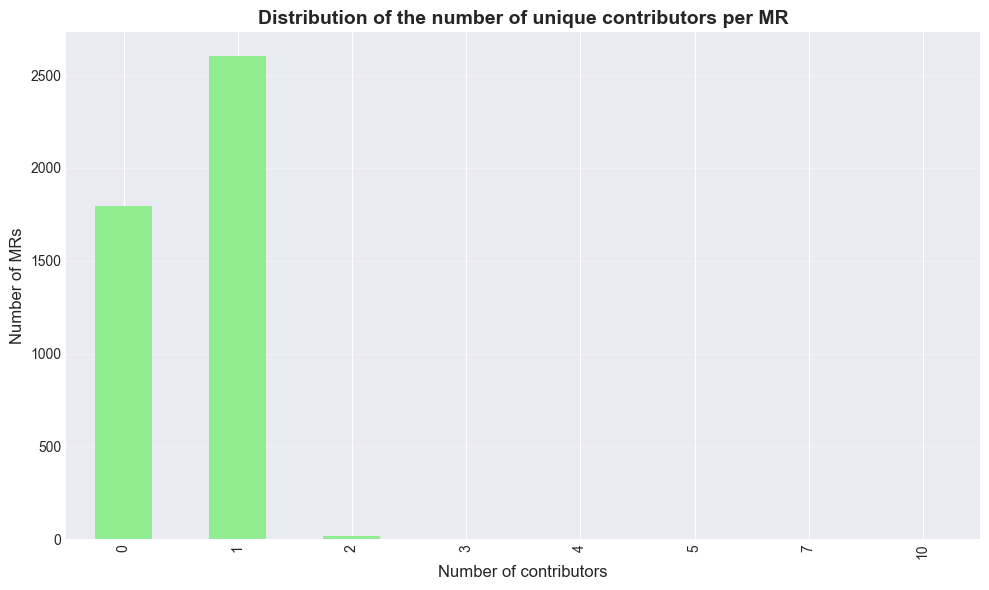

2.3 - Average time between commits...


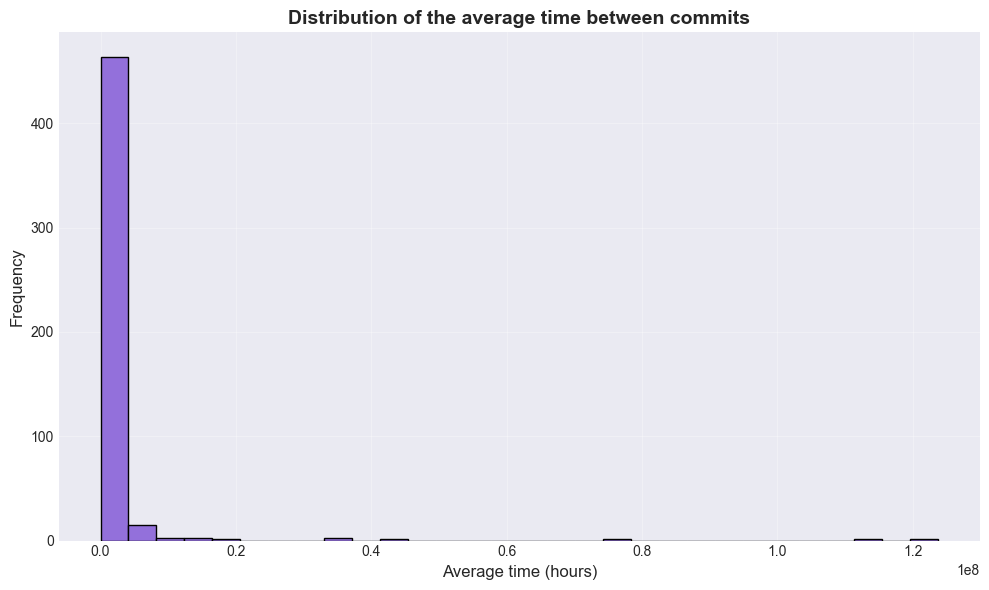


Statistics of time between commits:
count    4.900000e+02
mean     1.345967e+06
std      8.890223e+06
min      7.000000e+00
25%      3.227500e+02
50%      3.753000e+03
75%      8.638741e+04
max      1.237517e+08
Name: Mean_Time_between_commits, dtype: float64


In [99]:
print("2.1 - Distribution of the number of commits per MR...")
commits_stats = plot_commits_distribution(df, commit_col="#Commits")

print("2.2 - Analysis of unique contributors...")
commiters_dist = plot_commiters_analysis(df, commiters_col="#UniqueCommiters")

print("2.3 - Average time between commits...")
time_between_stats = plot_commit_time_analysis(df, time_col="Mean_Time_between_commits")

## Section 4 : Code Changes (Churn) Analysis

In [20]:
def plot_code_churn(
    df, additions_col="churn_addition", deletions_col="churn_deletions", figsize=(14, 6)
):
    """
    Code churn analysis (additions and deletions)

    Args:
        df: DataFrame
        additions_col: Name of the additions column
        deletions_col: Name of the deletions column
        figsize: Figure size
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Additions
    axes[0].hist(
        df[additions_col], bins=30, color="green", alpha=0.7, edgecolor="black"
    )
    axes[0].set_title("Distribution of code additions", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Number of lines added", fontsize=10)
    axes[0].set_ylabel("Frequency", fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Deletions
    axes[1].hist(df[deletions_col], bins=30, color="red", alpha=0.7, edgecolor="black")
    axes[1].set_title("Distribution of code deletions", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Number of lines deleted", fontsize=10)
    axes[1].set_ylabel("Frequency", fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nAdditions statistics:\n{df[additions_col].describe()}")
    print(f"\nDeletions statistics:\n{df[deletions_col].describe()}")

In [21]:
def plot_churn_scatter(
    df, additions_col="churn_addition", deletions_col="churn_deletions", figsize=(10, 8)
):
    """
    Scatter plot: additions vs deletions

    Args:
        df: DataFrame
        additions_col: Name of the additions column
        deletions_col: Name of the deletions column
        figsize: Figure size
    """
    plt.figure(figsize=figsize)
    plt.scatter(df[additions_col], df[deletions_col], alpha=0.5, c="purple")
    plt.title(
        "Relationship between additions and deletions", fontsize=14, fontweight="bold"
    )
    plt.xlabel("Lines added", fontsize=12)
    plt.ylabel("Lines deleted", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    correlation = df[[additions_col, deletions_col]].corr()
    print(f"\nCorrelation between additions and deletions:\n{correlation}")

    return correlation

In [22]:
def plot_mr_size_analysis(df, size_col="initial_mr_size", figsize=(10, 6)):
    """
    Initial MR size analysis

    Args:
        df: DataFrame
        size_col: Name of the size column
        figsize: Figure size
    """
    plt.figure(figsize=figsize)
    plt.hist(df[size_col], bins=30, color="orange", edgecolor="black")
    plt.title("Distribution of initial MR size", fontsize=14, fontweight="bold")
    plt.xlabel("Size (lines)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    stats = df[size_col].describe()
    print(f"\nMR size statistics:\n{stats}")

    return stats

# TEST : 

3.1 - Distribution of additions and deletions...


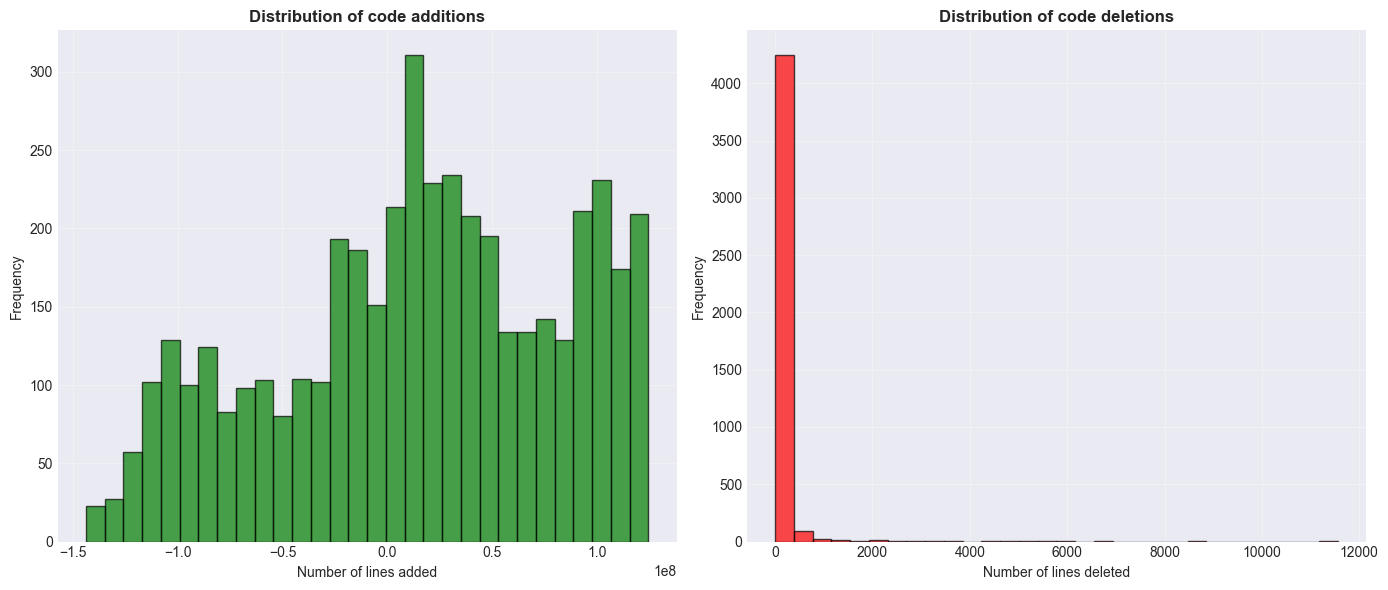


Additions statistics:
count    4.417000e+03
mean     1.441728e+07
std      6.816855e+07
min     -1.437178e+08
25%     -3.025154e+07
50%      1.795693e+07
75%      7.025595e+07
max      1.244232e+08
Name: churn_addition, dtype: float64

Deletions statistics:
count     4417.000000
mean        86.773149
std        409.095851
min          0.000000
25%          7.000000
50%         14.000000
75%         44.000000
max      11558.000000
Name: churn_deletions, dtype: float64
3.2 - Relationship between additions and deletions...


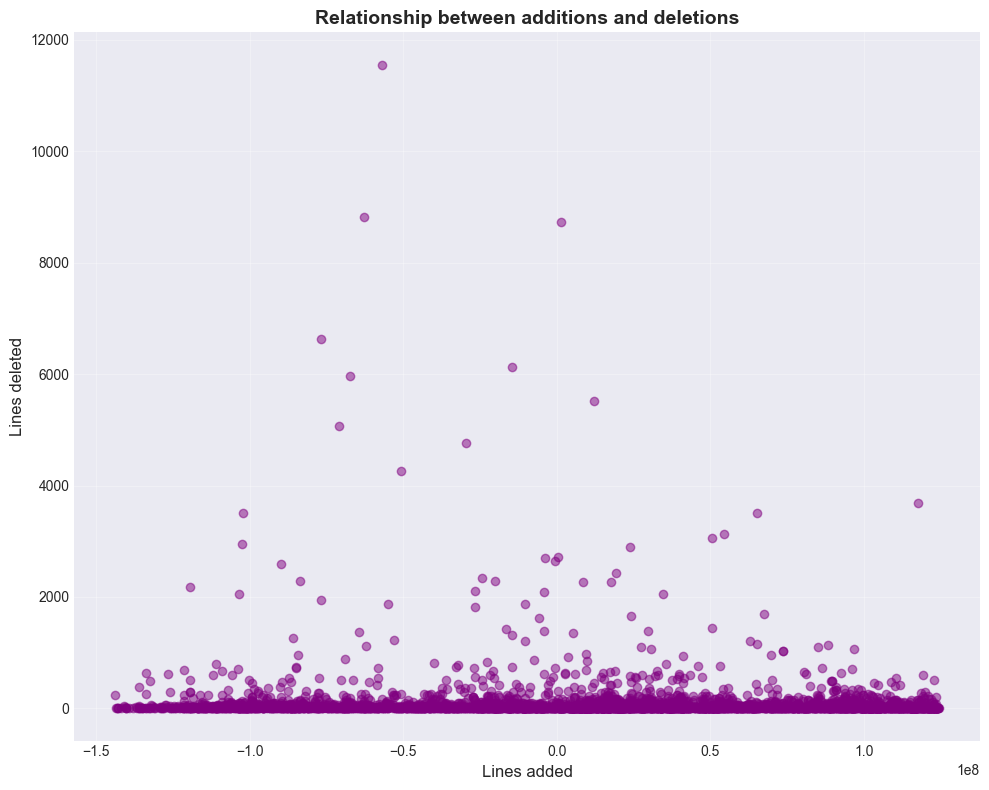


Correlation between additions and deletions:
                 churn_addition  churn_deletions
churn_addition         1.000000        -0.056158
churn_deletions       -0.056158         1.000000
3.3 - Analysis of initial MR size...


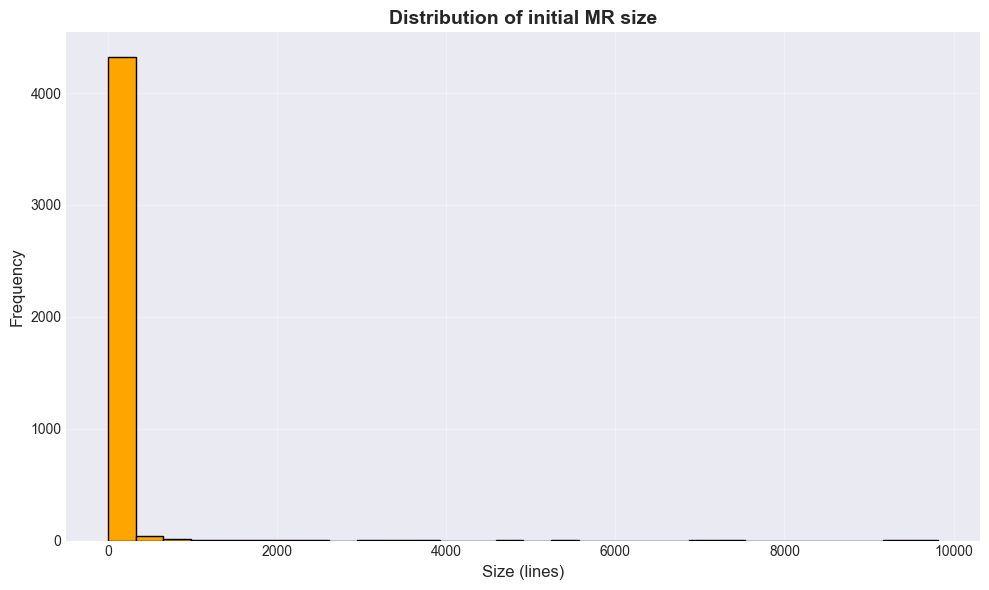


MR size statistics:
count    4417.000000
mean       56.564637
std       339.916828
min         0.000000
25%         6.000000
50%        12.000000
75%        29.000000
max      9821.000000
Name: initial_mr_size, dtype: float64


In [100]:
print("3.1 - Distribution of additions and deletions...")
plot_code_churn(df, additions_col="churn_addition", deletions_col="churn_deletions")

print("3.2 - Relationship between additions and deletions...")
churn_correlation = plot_churn_scatter(
    df, additions_col="churn_addition", deletions_col="churn_deletions"
)

print("3.3 - Analysis of initial MR size...")
mr_size_stats = plot_mr_size_analysis(df, size_col="initial_mr_size")

## SECTION 5: ANALYSE DES DISCUSSIONS ET COLLABORATION


In [23]:
def plot_discussions_analysis(df, discussions_col="#Discussions", figsize=(10, 6)):
    """
    Analysis of the number of discussions

    Args:
        df: DataFrame
        discussions_col: Name of the discussions column
        figsize: Figure size
    """
    plt.figure(figsize=figsize)

    discussions_dist = df[discussions_col].value_counts().sort_index()
    discussions_dist.plot(kind="bar", color="teal")
    plt.title(
        "Distribution of Number of Discussions per MR", fontsize=14, fontweight="bold"
    )
    plt.xlabel("Number of Discussions", fontsize=12)
    plt.ylabel("Number of MRs", fontsize=12)
    plt.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    stats = df[discussions_col].describe()
    print(f"\nDiscussion statistics:\n{stats}")

    return stats

In [24]:
def plot_collaboration_metrics(
    df,
    people_col="#people",
    reviewers_col="#reviewers",
    commiters_col="#commiters",
    discussionners_col="#discussionners",
    figsize=(14, 10),
):
    """
    Overview of collaboration metrics

    Args:
        df: DataFrame
        people_col: Column for number of people
        reviewers_col: Column for reviewers
        commiters_col: Column for committers
        discussionners_col: Column for discussion participants
        figsize: Figure size
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # People
    df[people_col].value_counts().sort_index().plot(
        kind="bar", ax=axes[0, 0], color="steelblue"
    )
    axes[0, 0].set_title("Number of People Involved", fontweight="bold")
    axes[0, 0].set_xlabel("Number of People")
    axes[0, 0].set_ylabel("Number of MRs")
    axes[0, 0].grid(True, alpha=0.3, axis="y")

    # Reviewers
    df[reviewers_col].value_counts().sort_index().plot(
        kind="bar", ax=axes[0, 1], color="coral"
    )
    axes[0, 1].set_title("Number of Reviewers", fontweight="bold")
    axes[0, 1].set_xlabel("Number of Reviewers")
    axes[0, 1].set_ylabel("Number of MRs")
    axes[0, 1].grid(True, alpha=0.3, axis="y")

    # Committers
    df[commiters_col].value_counts().sort_index().plot(
        kind="bar", ax=axes[1, 0], color="lightgreen"
    )
    axes[1, 0].set_title("Number of Committers", fontweight="bold")
    axes[1, 0].set_xlabel("Number of Committers")
    axes[1, 0].set_ylabel("Number of MRs")
    axes[1, 0].grid(True, alpha=0.3, axis="y")

    # Discussion participants
    df[discussionners_col].value_counts().sort_index().plot(
        kind="bar", ax=axes[1, 1], color="mediumpurple"
    )
    axes[1, 1].set_title("Number of Discussion Participants", fontweight="bold")
    axes[1, 1].set_xlabel("Number of Participants")
    axes[1, 1].set_ylabel("Number of MRs")
    axes[1, 1].grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()

In [25]:
def plot_comments_analysis(df, comments_col="comments", figsize=(10, 6)):
    """
    Analysis of the number of comments

    Args:
        df: DataFrame
        comments_col: Name of the comments column
        figsize: Figure size
    """
    plt.figure(figsize=figsize)

    df[comments_col].value_counts().sort_index().plot(kind="bar", color="salmon")
    plt.title(
        "Distribution of Number of Comments per MR", fontsize=14, fontweight="bold"
    )
    plt.xlabel("Number of Comments", fontsize=12)
    plt.ylabel("Number of MRs", fontsize=12)
    plt.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    stats = df[comments_col].describe()
    print(f"\nComment statistics:\n{stats}")

    return stats

## TEST 4

4.1 - Distribution of discussions...


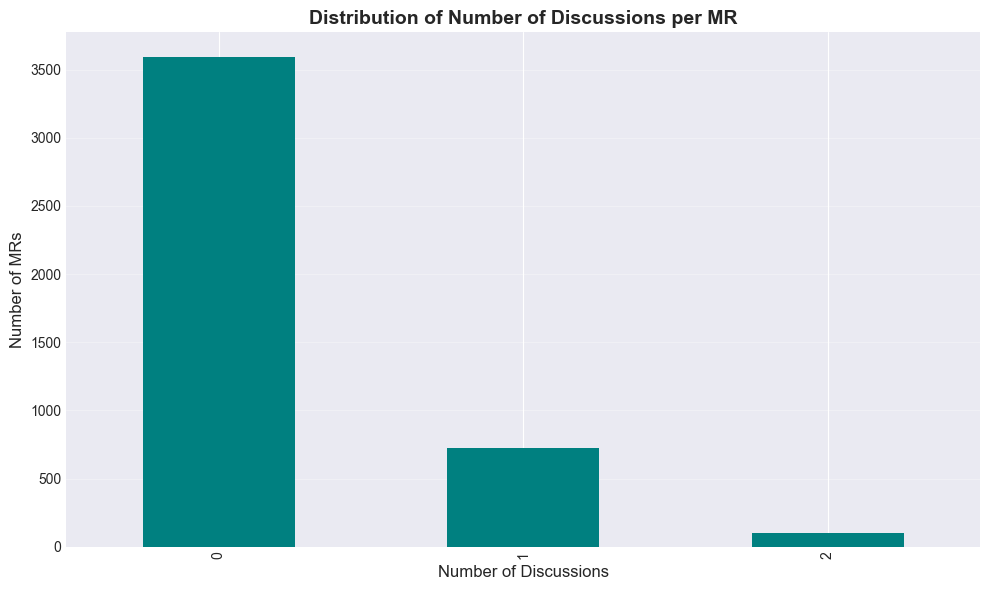


Discussion statistics:
count    4417.000000
mean        0.208739
std         0.458303
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         2.000000
Name: #Discussions, dtype: float64
4.2 - Overview of collaboration metrics...


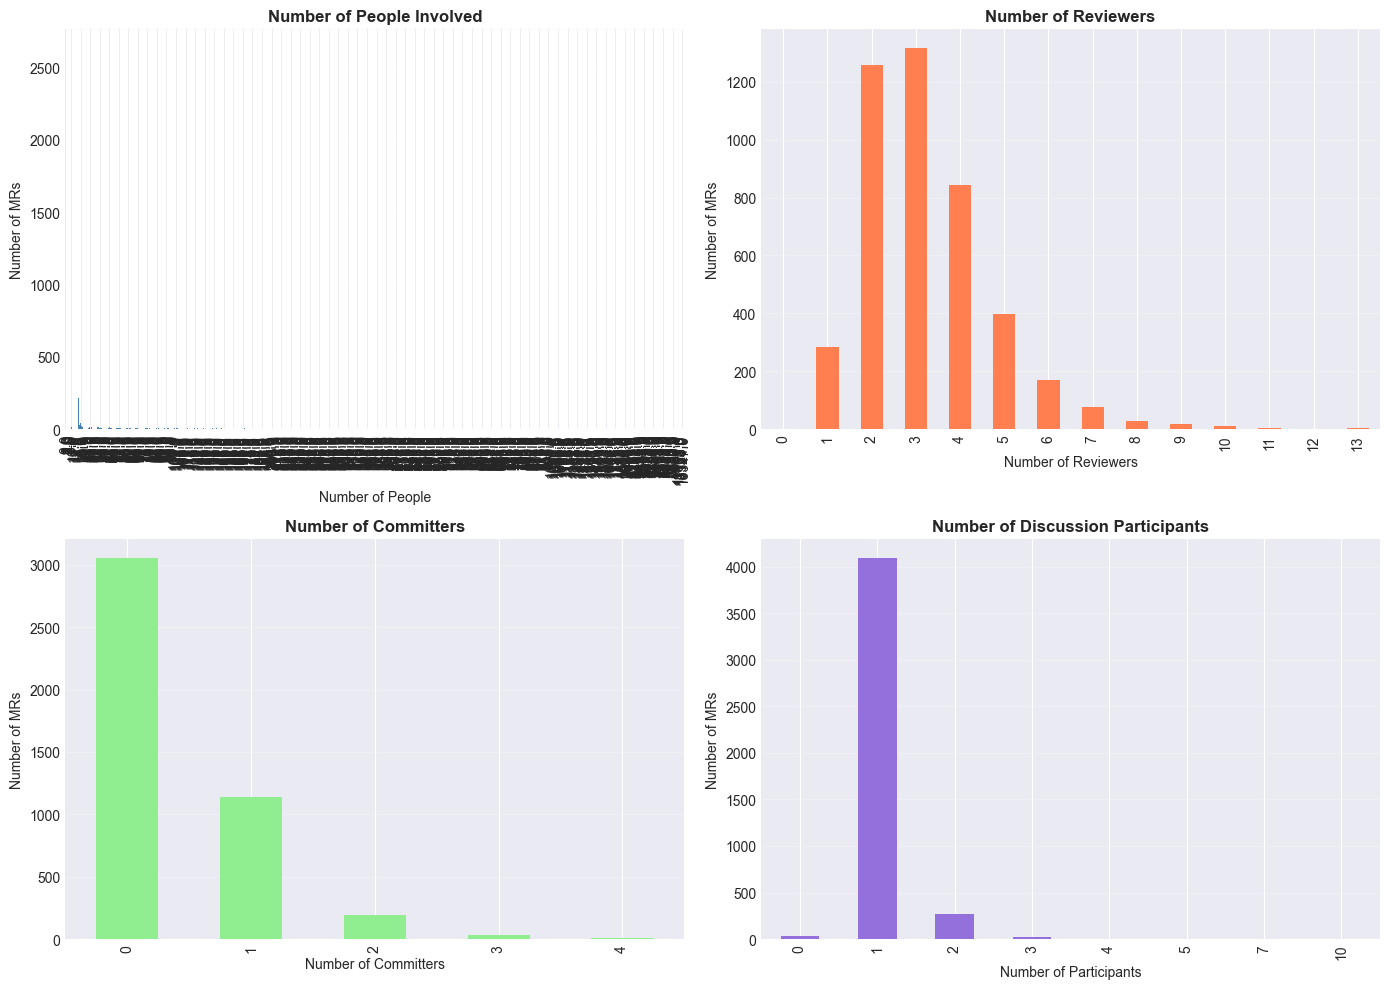

4.3 - Comments analysis...


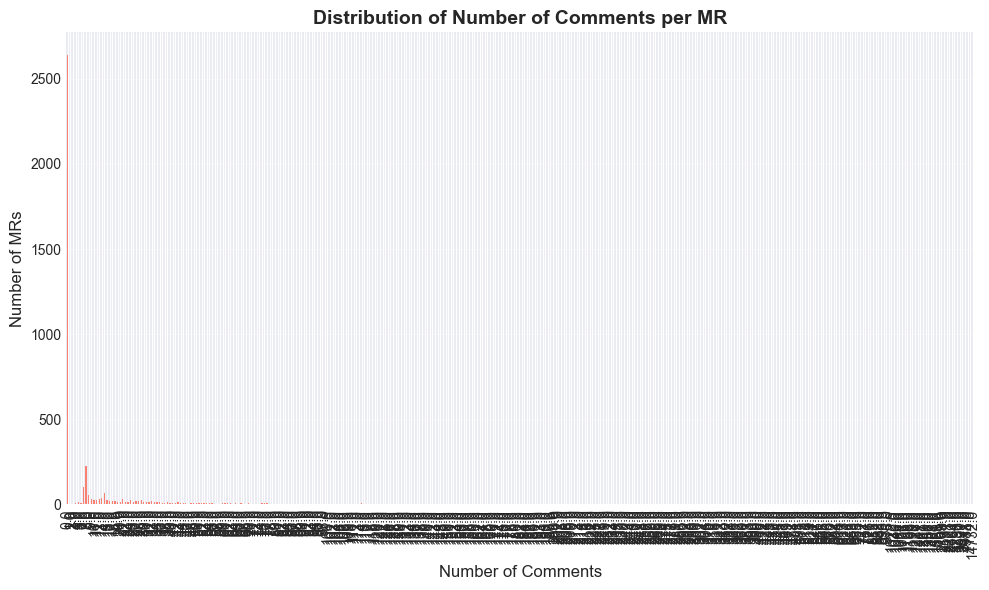


Comment statistics:
count     4417.000000
mean        45.726511
std        312.224694
min          0.000000
25%          0.000000
50%          0.000000
75%         16.000000
max      14732.000000
Name: comments, dtype: float64


In [101]:
print("4.1 - Distribution of discussions...")
discussions_stats = plot_discussions_analysis(df, discussions_col="#Discussions")

print("4.2 - Overview of collaboration metrics...")
plot_collaboration_metrics(
    df,
    people_col="#people",
    reviewers_col="#reviewers",
    commiters_col="#commiters",
    discussionners_col="#discussionners",
)

print("4.3 - Comments analysis...")
comments_stats = plot_comments_analysis(df, comments_col="comments")

## SECTION 6: FILE ANALYSIS

In [26]:
def plot_files_modified(df, files_col="modified_files", figsize=(10, 6)):
    """
    Analysis of the number of modified files

    Args:
        df: DataFrame
        files_col: Name of the modified files column
        figsize: Figure size
    """
    plt.figure(figsize=figsize)

    df[files_col].value_counts().sort_index().plot(kind="bar", color="gold")
    plt.title(
        "Distribution of the number of modified files per MR",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Number of files", fontsize=12)
    plt.ylabel("Number of MRs", fontsize=12)
    plt.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    stats = df[files_col].describe()
    print(f"\nModified files statistics:\n{stats}")

    return stats

In [27]:
def plot_filetypes_distribution(df, filetypes_col="filetypes", figsize=(10, 6)):
    """
    Distribution of file types

    Args:
        df: DataFrame
        filetypes_col: Name of the file types column
        figsize: Figure size
    """
    plt.figure(figsize=figsize)

    df[filetypes_col].value_counts().head(15).plot(kind="barh", color="skyblue")
    plt.title("Top 15 modified file types", fontsize=14, fontweight="bold")
    plt.xlabel("Number of MRs", fontsize=12)
    plt.ylabel("File types", fontsize=12)
    plt.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

In [28]:
def plot_entropy_analysis(df, entropy_col="hist_entropy", figsize=(10, 6)):
    """
    Historical entropy analysis

    Args:
        df: DataFrame
        entropy_col: Name of the entropy column
        figsize: Figure size
    """
    plt.figure(figsize=figsize)
    plt.hist(df[entropy_col], bins=30, color="indigo", edgecolor="black")
    plt.title("Distribution of historical entropy", fontsize=14, fontweight="bold")
    plt.xlabel("Entropy", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    stats = df[entropy_col].describe()
    print(f"\nEntropy statistics:\n{stats}")

    return stats

## TEST : 


5.1 - Distribution of the number of modified files...


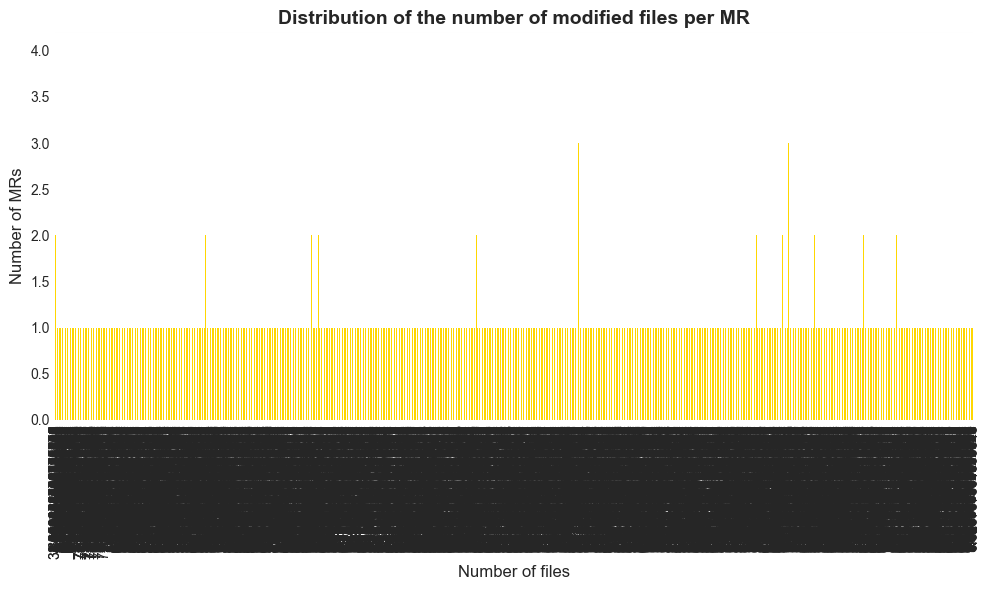


Modified files statistics:
count    4417.000000
mean        9.131768
std         0.746310
min         0.000000
25%         9.002955
50%         9.438860
75%         9.567045
max         9.628788
Name: modified_files, dtype: float64

5.2 - Distribution of file types...


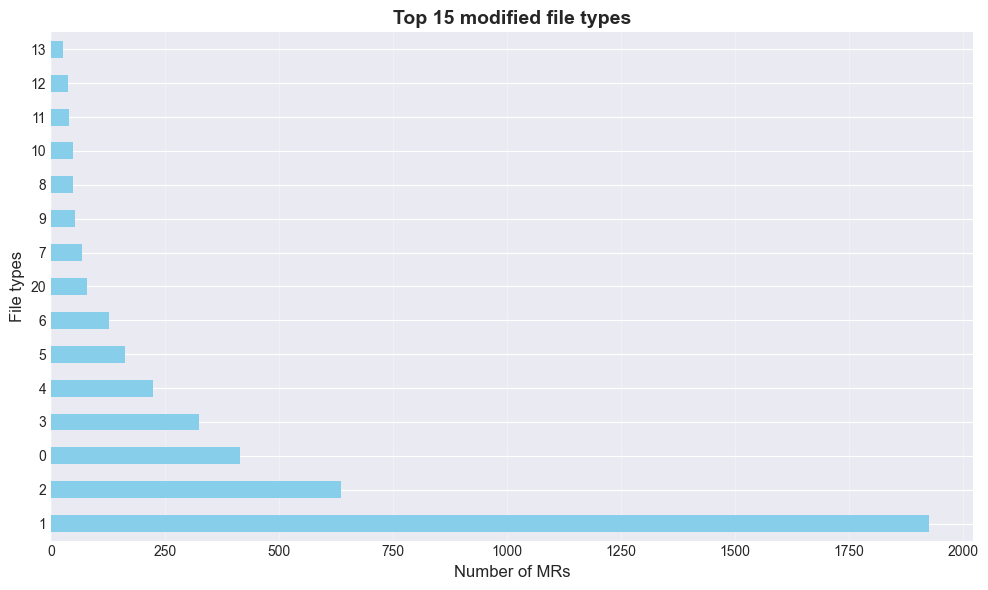


5.3 - Historical entropy analysis...


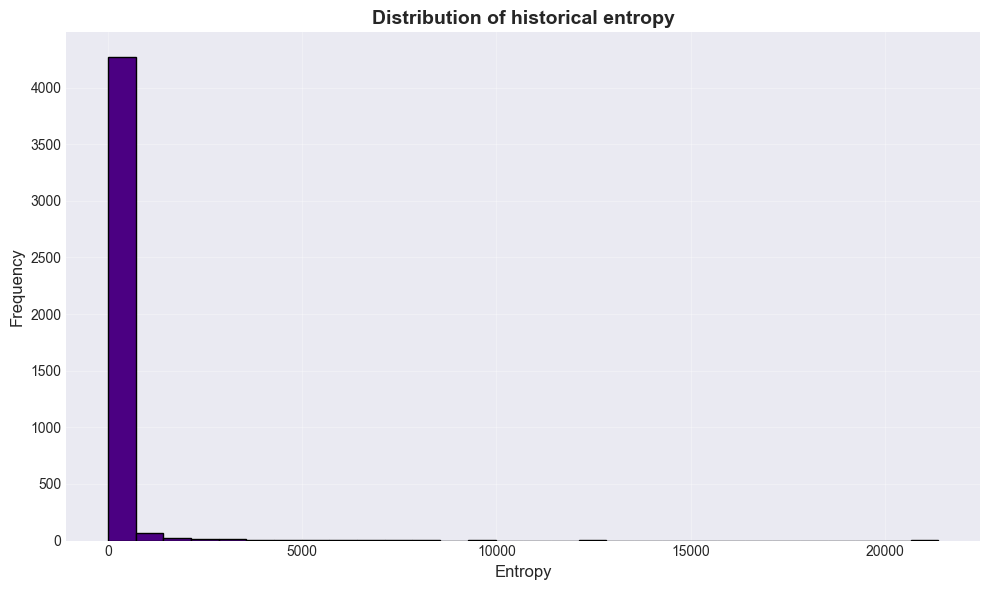


Entropy statistics:
count     4417.000000
mean       143.337786
std        632.734220
min          0.000000
25%         14.000000
50%         28.000000
75%         79.000000
max      21379.000000
Name: hist_entropy, dtype: float64


In [103]:
print("\n5.1 - Distribution of the number of modified files...")
files_stats = plot_files_modified(df, files_col="modified_files")

print("\n5.2 - Distribution of file types...")
plot_filetypes_distribution(df, filetypes_col="filetypes")

print("\n5.3 - Historical entropy analysis...")
entropy_stats = plot_entropy_analysis(df, entropy_col="hist_entropy")

## SECTION 7: ANALYSIS OF STATES AND REWORK


In [29]:
def plot_state_distribution(df, state_col="state", figsize=(8, 8)):
    """
    Distribution of MR states

    Args:
        df: DataFrame
        state_col: Name of the state column
        figsize: Figure size
    """
    plt.figure(figsize=figsize)

    state_counts = df[state_col].value_counts()
    colors = plt.cm.Set3(range(len(state_counts)))
    plt.pie(
        state_counts,
        labels=state_counts.index,
        autopct="%1.1f%%",
        colors=colors,
        startangle=90,
    )
    plt.title("Distribution of MR States", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"\nNumber of MRs per state:\n{state_counts}")

    return state_counts

In [30]:
def plot_rework_analysis(df, rework_col="rework_size", figsize=(10, 6)):
    """
    Analysis of rework size

    Args:
        df: DataFrame
        rework_col: Name of the rework column
        figsize: Figure size
    """
    df_filtered = df[df[rework_col] > 0].copy()

    plt.figure(figsize=figsize)
    plt.hist(df_filtered[rework_col], bins=30, color="crimson", edgecolor="black")
    plt.title(
        "Distribution of Rework Size (MRs with rework)", fontsize=14, fontweight="bold"
    )
    plt.xlabel("Rework Size", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nPercentage of MRs with rework: {len(df_filtered) / len(df) * 100:.2f}%")
    stats = df_filtered[rework_col].describe()
    print(f"\nRework statistics:\n{stats}")

    return stats

## TEST : 

6.1 - Distribution of MR states...


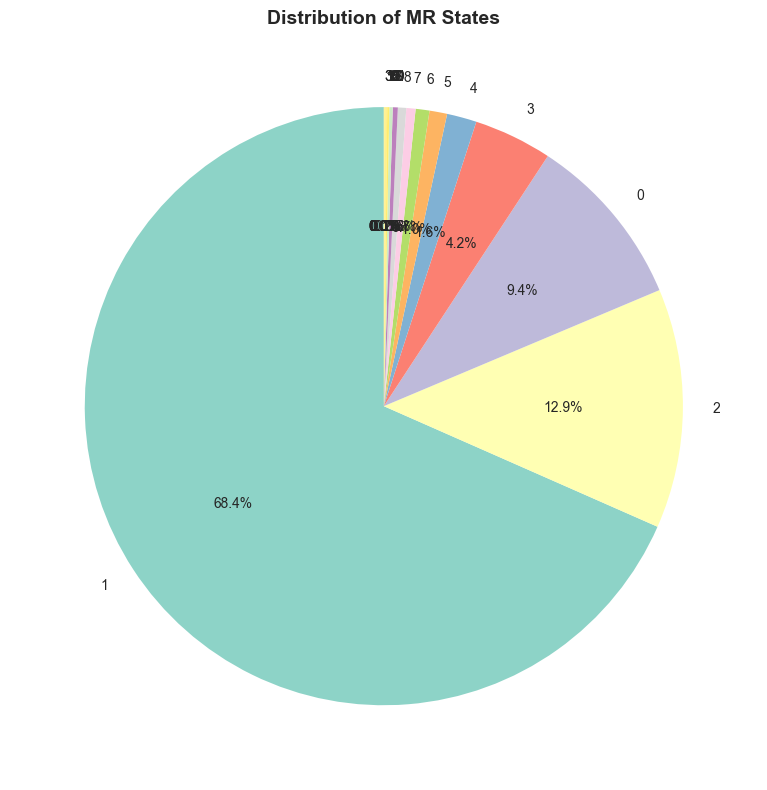


Number of MRs per state:
state
1     3021
2      572
0      416
3      187
4       71
5       42
6       33
7       22
8       20
9       12
11       8
10       5
16       2
12       2
13       1
15       1
32       1
35       1
Name: count, dtype: int64
6.2 - Rework size analysis...


TypeError: '>' not supported between instances of 'str' and 'int'

In [104]:
print("6.1 - Distribution of MR states...")
state_counts = plot_state_distribution(df, state_col="state")

print("6.2 - Rework size analysis...")
rework_stats = plot_rework_analysis(df, rework_col="rework_size")

## SECTION 8: CORRELATION ANALYSIS AND INSIGHTS

In [31]:
def plot_correlation_matrix(df, columns=None, figsize=(12, 10)):
    """
    Correlation matrix between numerical variables

    Args:
        df: DataFrame
        columns: List of columns to include (None = all numerical columns)
        figsize: Figure size
    """
    if columns is None:
        # Select only numerical columns
        numeric_df = df.select_dtypes(include=[np.number])
    else:
        numeric_df = df[columns]

    correlation = numeric_df.corr()

    plt.figure(figsize=figsize)
    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=1,
        cbar_kws={"shrink": 0.8},
    )
    plt.title("Correlation Matrix", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return correlation

In [32]:
def analyze_mr_complexity(
    df,
    commits_col="#Commits",
    files_col="modified_files",
    discussions_col="#Discussions",
    people_col="#people",
    figsize=(12, 8),
):
    """
    Analysis of MR complexity based on several metrics

    Args:
        df: DataFrame
        commits_col: Commits column
        files_col: Files column
        discussions_col: Discussions column
        people_col: People column
        figsize: Figure size
    """
    # Create a complexity score
    df["complexity_score"] = (
        df[commits_col] + df[files_col] + df[discussions_col] + df[people_col]
    )

    plt.figure(figsize=figsize)
    plt.scatter(
        df["complexity_score"], df[commits_col], alpha=0.5, c="blue", label="Commits"
    )
    plt.scatter(
        df["complexity_score"], df[files_col], alpha=0.5, c="red", label="Files"
    )
    plt.scatter(
        df["complexity_score"],
        df[discussions_col],
        alpha=0.5,
        c="green",
        label="Discussions",
    )
    plt.title("MR Complexity Analysis", fontsize=14, fontweight="bold")
    plt.xlabel("Complexity Score", fontsize=12)
    plt.ylabel("Metric Values", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nTop 10 most complex MRs:")
    print(
        df.nlargest(10, "complexity_score")[
            [
                "MR_ID",
                "complexity_score",
                commits_col,
                files_col,
                discussions_col,
                people_col,
            ]
        ]
    )

    return df["complexity_score"]

In [33]:
def plot_project_comparison(
    df, project_col="Project_ID", metric_col="#Commits", figsize=(12, 6)
):
    """
    Comparison of a metric between different projects

    Args:
        df: DataFrame
        project_col: Project column name
        metric_col: Metric to compare
        figsize: Figure size
    """
    project_stats = df.groupby(project_col)[metric_col].agg(["mean", "median", "sum"])

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    project_stats["mean"].plot(kind="bar", ax=axes[0], color="steelblue")
    axes[0].set_title(f"Mean of {metric_col} per project", fontweight="bold")
    axes[0].set_xlabel("Project ID")
    axes[0].set_ylabel("Mean")
    axes[0].grid(True, alpha=0.3, axis="y")

    project_stats["median"].plot(kind="bar", ax=axes[1], color="coral")
    axes[1].set_title(f"Median of {metric_col} per project", fontweight="bold")
    axes[1].set_xlabel("Project ID")
    axes[1].set_ylabel("Median")
    axes[1].grid(True, alpha=0.3, axis="y")

    project_stats["sum"].plot(kind="bar", ax=axes[2], color="lightgreen")
    axes[2].set_title(f"Total of {metric_col} per project", fontweight="bold")
    axes[2].set_xlabel("Project ID")
    axes[2].set_ylabel("Total")
    axes[2].grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()

    print(f"\nStatistics of {metric_col} per project:\n{project_stats}")

    return project_stats

## Test  : 

7.1 - Correlation matrix (key columns)...


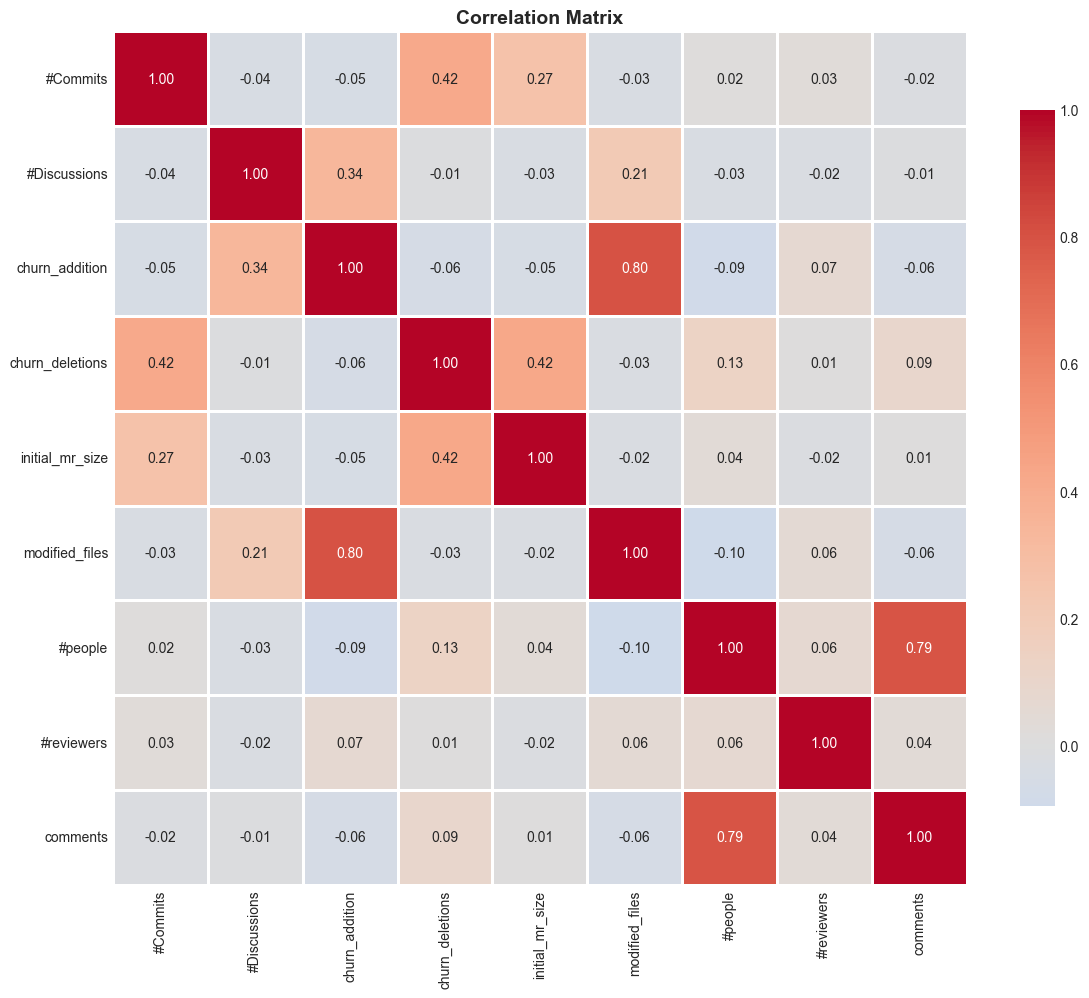

7.2 - MR complexity analysis...


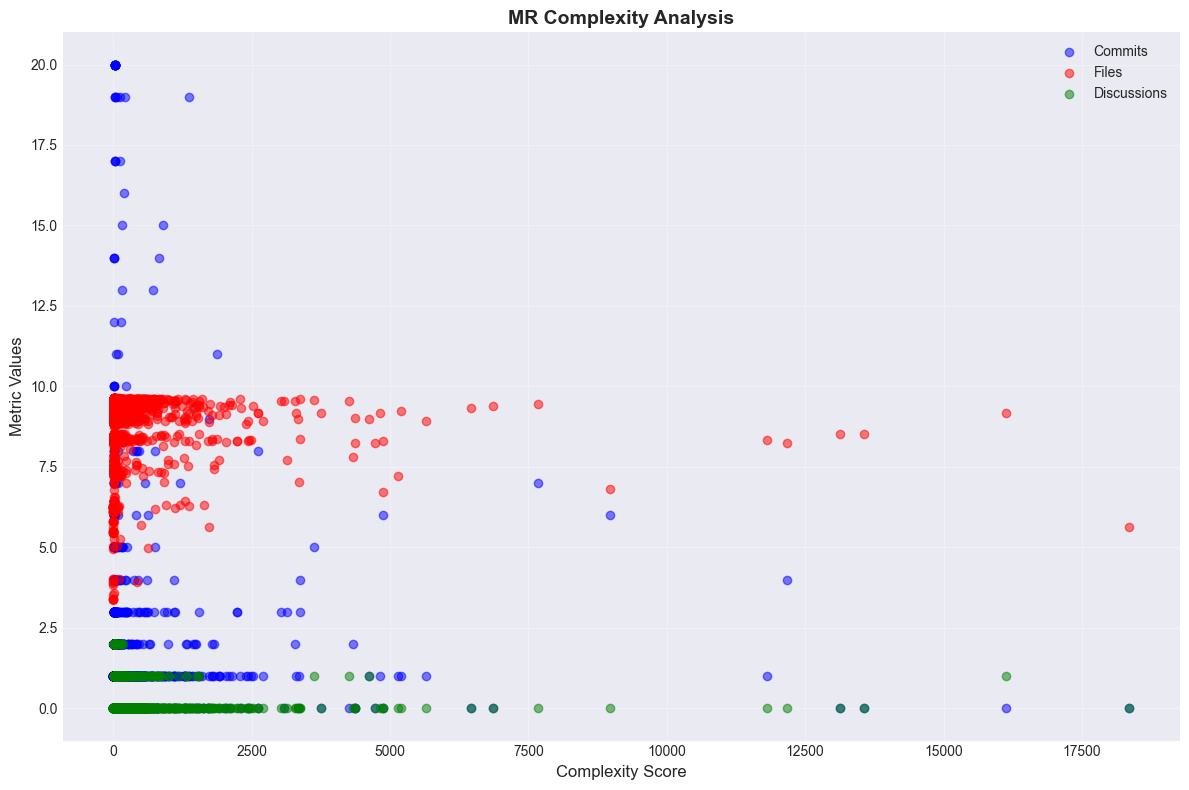


Top 10 most complex MRs:
      MR_ID  complexity_score  #Commits  modified_files  #Discussions  #people
4387     30      18352.639495         0        5.639495             0  18347.0
2802   1615      16134.181925         0        9.181925             1  16124.0
3669    748      13558.514064         0        8.514064             0  13550.0
3670    747      13136.516159         0        8.516159             0  13128.0
3970    447      12174.249024         4        8.249024             0  12162.0
3810    607      11812.348721         1        8.348721             0  11803.0
4327     90       8969.807764         6        6.807764             0   8957.0
1987   2433       7676.468013         7        9.468013             0   7660.0
2365   2055       6859.402652         0        9.402652             0   6850.0
2590   1827       6456.318432         0        9.318432             0   6447.0
7.3 - Project comparison (Commits)...


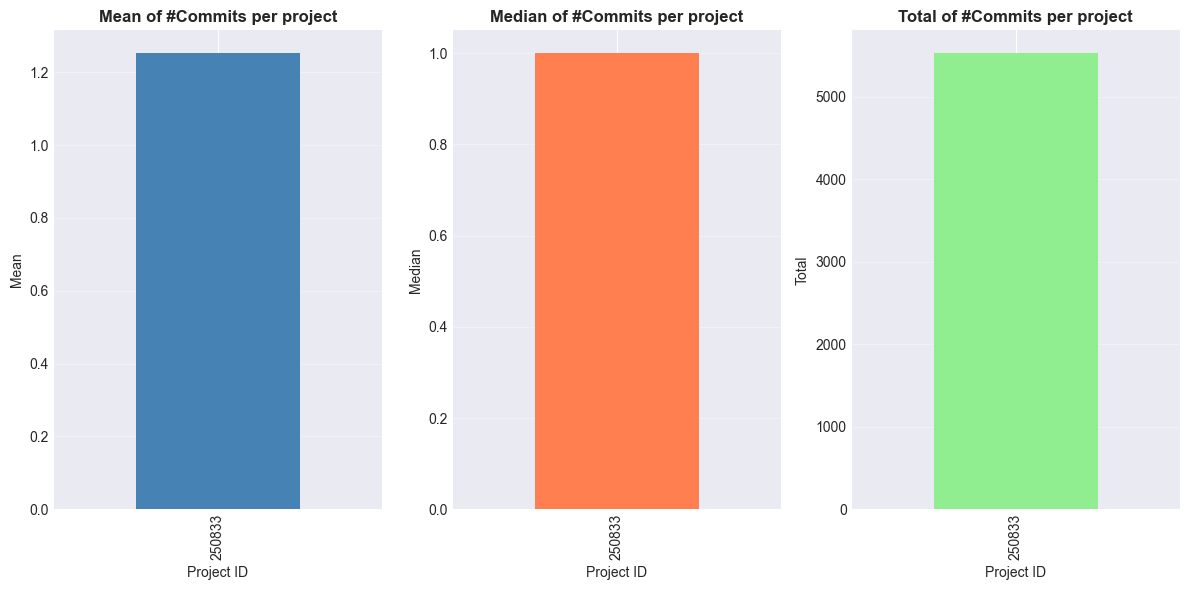


Statistics of #Commits per project:
                mean  median   sum
Project_ID                        
250833      1.251981     1.0  5530
7.4 - Project comparison (Discussions)...


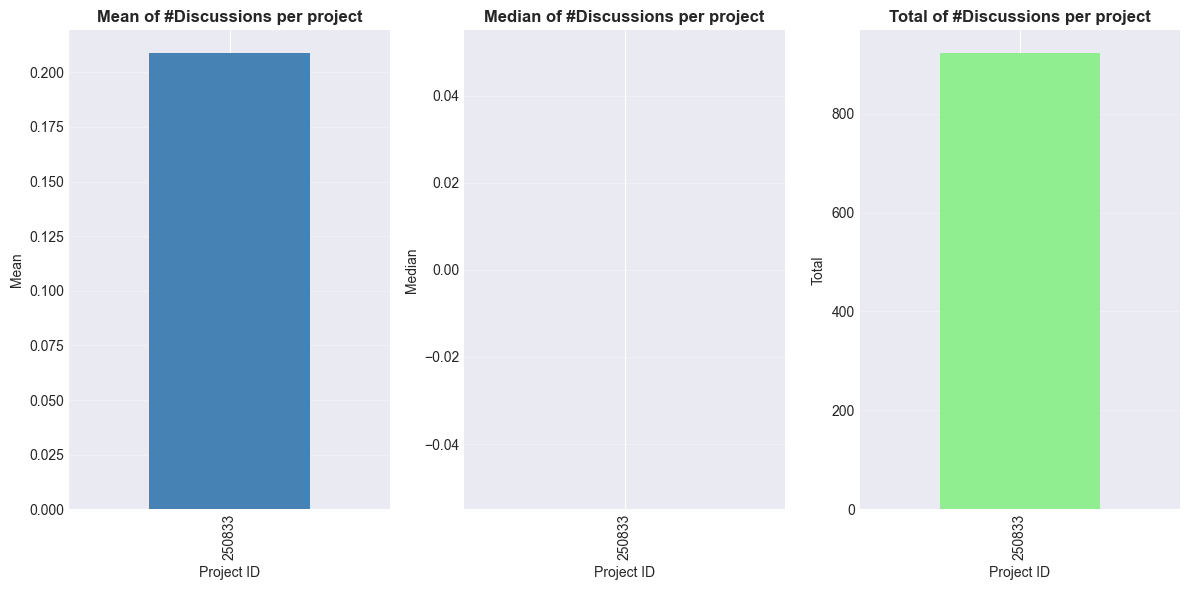


Statistics of #Discussions per project:
                mean  median  sum
Project_ID                       
250833      0.208739     0.0  922
7.5 - Project comparison (Modified files)...


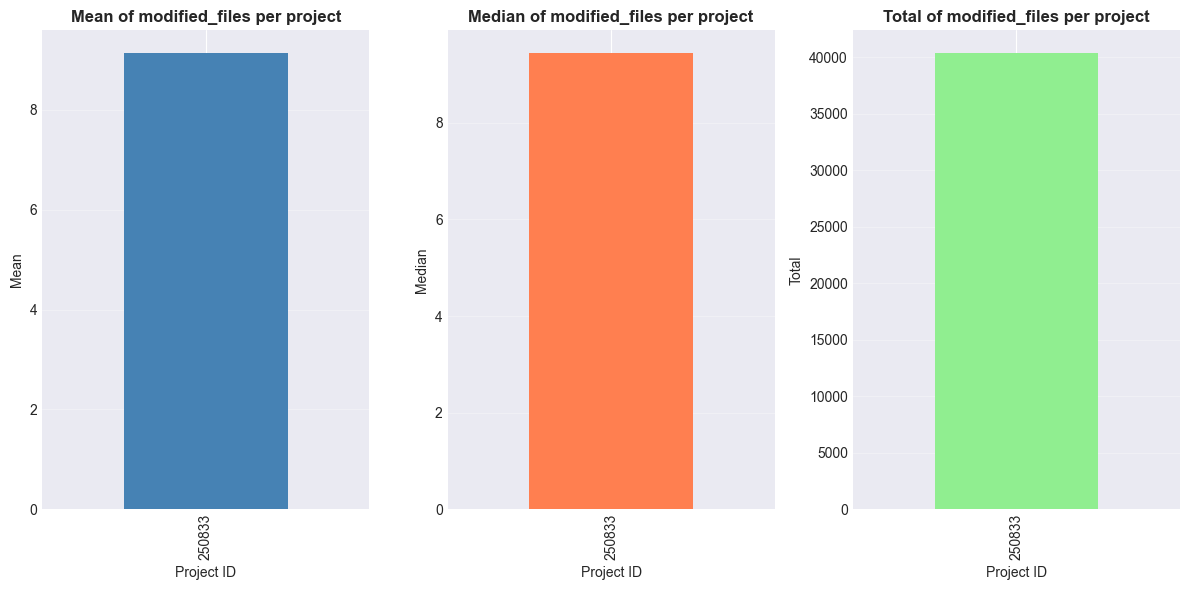


Statistics of modified_files per project:
                mean   median           sum
Project_ID                                 
250833      9.131768  9.43886  40335.019933


In [105]:
print("7.1 - Correlation matrix (key columns)...")
key_columns = [
    "#Commits",
    "#Discussions",
    "churn_addition",
    "churn_deletions",
    "initial_mr_size",
    "modified_files",
    "#people",
    "#reviewers",
    "comments",
]
correlation_matrix = plot_correlation_matrix(df, columns=key_columns)

print("7.2 - MR complexity analysis...")
complexity_scores = analyze_mr_complexity(
    df,
    commits_col="#Commits",
    files_col="modified_files",
    discussions_col="#Discussions",
    people_col="#people",
)

print("7.3 - Project comparison (Commits)...")
project_commits = plot_project_comparison(
    df, project_col="Project_ID", metric_col="#Commits"
)

print("7.4 - Project comparison (Discussions)...")
project_discussions = plot_project_comparison(
    df, project_col="Project_ID", metric_col="#Discussions"
)

print("7.5 - Project comparison (Modified files)...")
project_files = plot_project_comparison(
    df, project_col="Project_ID", metric_col="modified_files"
)